In [1]:
!pip install psycopg2-binary sqlalchemy pandas

In [4]:
import matplotlib.pyplot as plt

In [5]:
df.shape

(558837, 20)

In [8]:
pd.set_option('display.max_columns', 20)

In [6]:
df

,year_made,maker,model,trim,body,transmission,vin,state,condition,odometer_miles,color,interior,seller,mmr,selling_price,sale_time,sale_date,maker_region,sale_year,sale_month
0,2011,Toyota,Camry,SE,Sedan,None,4t1bf3ek6bu140838,PA,2.0,117212.0,gray,black,pohanka lexus,7775.0,7600.0,2:00:00 AM,2015-06-05,USA,2015,Jun
1,2013,Chevrolet,Sonic,LT,Sedan,None,1g1jc5sg5d4215447,PA,25.0,27629.0,black,black,gm financial,8925.0,7500.0,6:15:00 AM,2015-05-28,USA,2015,May
2,2008,Mercury,Sable,Base,Sedan,automatic,1mehm40w38g620250,GA,26.0,78800.0,white,gray,kern automotive group inc,6875.0,6100.0,2:30:00 AM,2015-06-09,USA,2015,Jun
3,2008,Dodge,None,None,None,None,2d8hn44h38r804453,AB,26.0,177766.0,red,gray,go auto outlet west,4075.0,4000.0,4:30:00 AM,2015-05-28,Canada,2015,May
4,2003,GMC,None,None,None,automatic,1g1yy22gx35104366,FL,41.0,113898.0,gray,gray,autobuy,10000.0,10500.0,2:10:00 AM,2015-05-28,USA,2015,May
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,2013,Ford,Focus,SE,Sedan,automatic,1fadp3f21dl237467,NC,32.0,55837.0,red,gray,coastal union remarketing,8850.0,9600.0,2:30:00 AM,2015-06-01,USA,2015,Jun
558833,2013,Ford,Focus,SE,Sedan,None,1fadp3f28dl213103,PA,29.0,57172.0,white,black,dtg operations inc,8775.0,8500.0,2:00:00 AM,2015-06-05,USA,2015,Jun
558834,2013,Ford,Focus,SE,Hatchback,automatic,1fadp3k29dl152611,PA,35.0,51968.0,gray,gray,the hertz corporation,9275.0,9100.0,2:00:00 AM,2015-05-29,USA,2015,May
558835,2013,Ford,Focus,SE,Hatchback,automatic,1fadp3k24dl341540,PA,31.0,53971.0,red,black,the hertz corporation,9200.0,8800.0,2:00:00 AM,2015-06-05,USA,2015,Jun


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year_made       558837 non-null  int64  
 1   maker           558802 non-null  object 
 2   model           548438 non-null  object 
 3   trim            548186 non-null  object 
 4   transmission    493481 non-null  object 
 5   vin             558837 non-null  object 
 6   state           558811 non-null  object 
 7   condition       547043 non-null  float64
 8   odometer_miles  558743 non-null  float64
 9   color           533402 non-null  object 
 10  interior        541012 non-null  object 
 11  seller          558811 non-null  object 
 12  mmr             558825 non-null  float64
 13  selling_price   558799 non-null  float64
 14  sale_time       558825 non-null  object 
 15  sale_date       558799 non-null  object 
 16  maker_region    558837 non-null  object 
 17  sale_year 

In [7]:
df.isna().sum()

year_made             0
maker                35
model             10399
trim              10651
transmission      65356
vin                   0
state                26
condition         11794
odometer_miles       94
color             25435
interior          17825
seller               26
mmr                  12
selling_price        38
sale_time            12
sale_date            38
maker_region          0
sale_year            38
sale_month           38
body                  0
dtype: int64

In [9]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
558832    False
558833    False
558834    False
558835    False
558836    False
Length: 558837, dtype: bool

In [8]:
df.describe()

,year_made,condition,odometer_miles,mmr,selling_price
count,558837.000000,547043.000000,558743.000000,558825.000000,558799.000000
mean,2010.038927,30.672188,68320.437548,13769.372657,13611.356296
std,3.966864,13.403260,53398.058707,9679.742249,9749.728196
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [44]:
df['price_diff'] = df['selling_price'] - df['mmr']

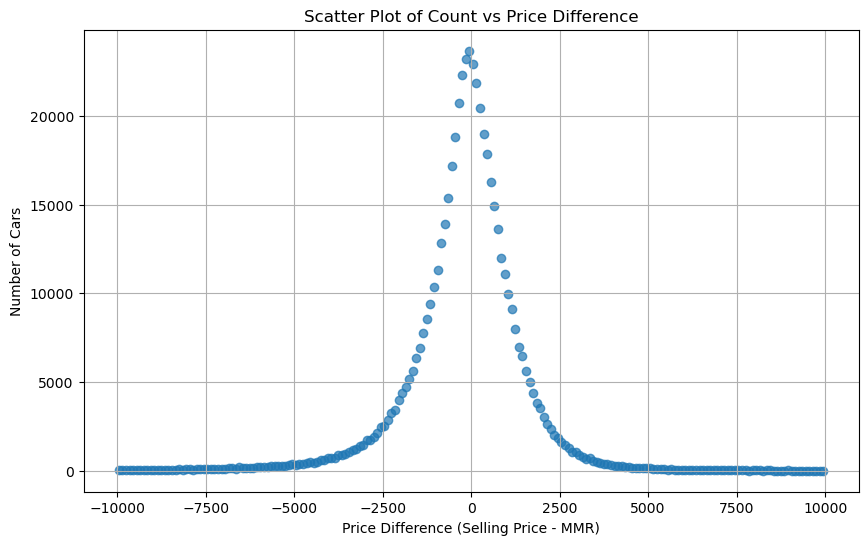

In [55]:
bins = pd.cut(df['price_diff'], bins=range(-10000, 10001, 100))

price_diff_counts = bins.value_counts().sort_index()

x = [interval.mid for interval in price_diff_counts.index]
y = price_diff_counts.values

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.7)
plt.title('Scatter Plot of Count vs Price Difference')
plt.xlabel('Price Difference (Selling Price - MMR)')
plt.ylabel('Number of Cars')
plt.grid(True)
plt.show()

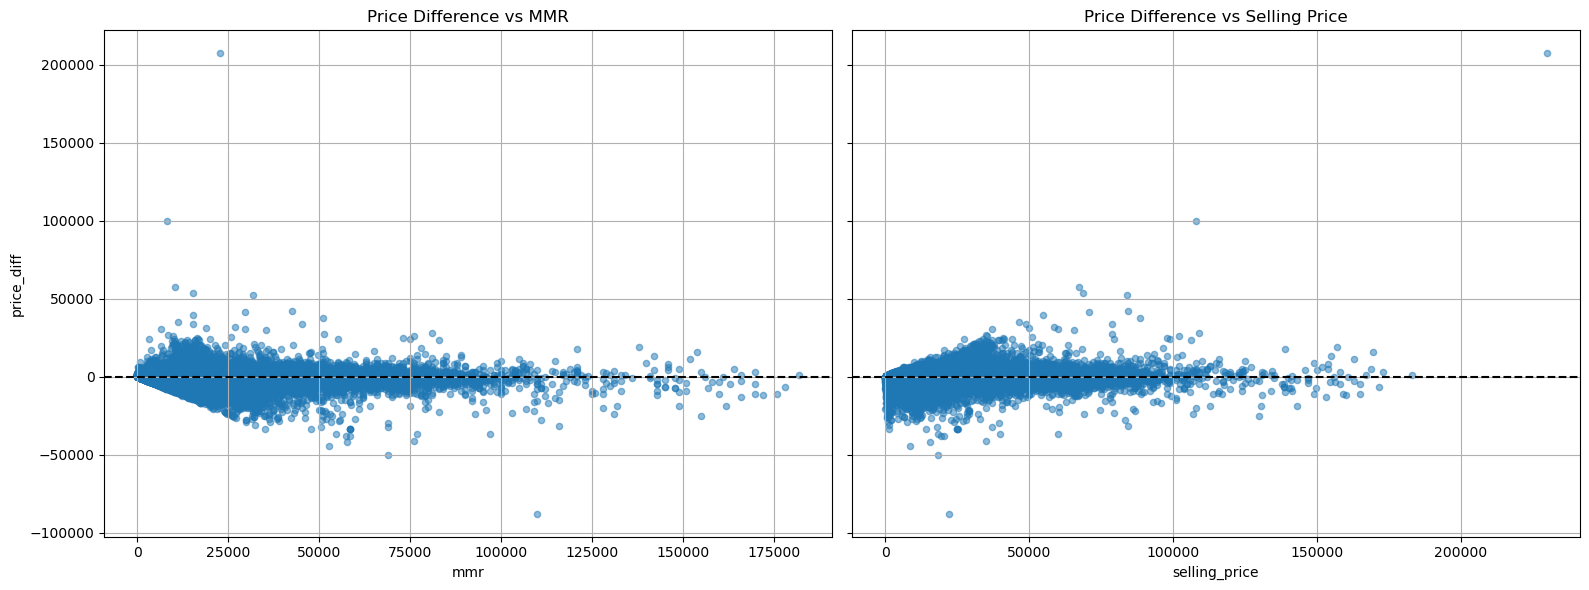

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

df.dropna(subset=['mmr', 'price_diff']).plot(
    kind='scatter',
    x='mmr',
    y='price_diff',
    alpha=0.5,
    ax=axes[0],
    title='Price Difference vs MMR'
)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].grid(True)

df.dropna(subset=['selling_price', 'price_diff']).plot(
    kind='scatter',
    x='selling_price',
    y='price_diff',
    alpha=0.5,
    ax=axes[1],
    title='Price Difference vs Selling Price'
)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].grid(True)

plt.tight_layout()
plt.show()

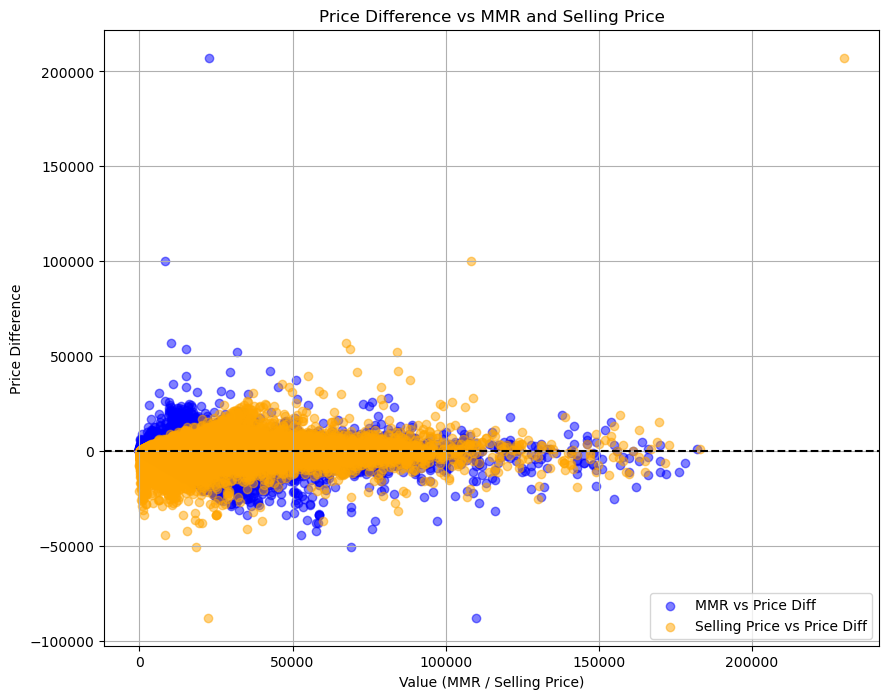

In [60]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df['mmr'], 
    df['price_diff'], 
    alpha=0.5, 
    label='MMR vs Price Diff', 
    color='blue'
)

plt.scatter(
    df['selling_price'], 
    df['price_diff'], 
    alpha=0.5, 
    label='Selling Price vs Price Diff', 
    color='orange'
)

plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Value (MMR / Selling Price)')
plt.ylabel('Price Difference')
plt.title('Price Difference vs MMR and Selling Price')
plt.legend()
plt.grid(True)
plt.show()

In [106]:
top_vins = df[['vin', 'condition', 'odometer_miles', 'mmr', 'selling_price', 'price_diff']].dropna().sort_values(by='price_diff', ascending=False).head(10)
print(top_vins)

                      vin  condition  odometer_miles      mmr  selling_price  \
363823  1fmcu9j98eua23833       43.0         27802.0  22800.0       230000.0   
351195  1fmcu0d77aka54695       37.0         82985.0   8250.0       108200.0   
412004  3n1bc1cp2ck235725       38.0         10926.0  10350.0        67500.0   
410541  2t1burhe2fc353484       22.0           517.0  15250.0        68900.0   
88659   wd3pe8cc5d5801059        5.0          1575.0  31900.0        84000.0   
441357  wba3r1c5xfk193672       47.0          6009.0  42500.0        84500.0   
30608   wd3pf4cd5c5624350        4.0         51971.0  29500.0        71000.0   
253906  1gnsckkc2fr197462        4.0         12710.0  15300.0        55000.0   
102506  wba6b4c57fd761030       49.0          7053.0  51000.0        88500.0   
49512   1gnskjkc4fr158207        4.0         19410.0  11100.0        46400.0   

        price_diff  
363823    207200.0  
351195     99950.0  
412004     57150.0  
410541     53650.0  
88659      521

In [107]:
top_vins = df[['vin', 'condition', 'odometer_miles', 'mmr', 'selling_price', 'price_diff']].dropna().sort_values(by='price_diff', ascending=False).tail(10)
print(top_vins)

                      vin  condition  odometer_miles       mmr  selling_price  \
328554  3fa6p0h90er320201       45.0         25317.0   47800.0        14200.0   
287521  jtjhy00w084002896        2.0         58499.0   35200.0         1400.0   
430881  1gks2bkc6fr297077        2.0             1.0   54700.0        18200.0   
154674  salgs2tf8ea184005       49.0          9925.0   97000.0        60000.0   
103633  sajwj2gd1e8v62687        1.0          9501.0   77000.0        40000.0   
44967   wdbsk7ba3cf169124       39.0         26776.0   58400.0        20500.0   
541855  1g1yf3d7xe5125570        4.0         13320.0   57500.0        19400.0   
15831   1g1ym2d71e5101934       45.0         12470.0   57600.0        15700.0   
98555   1gnscckcxfr548110        2.0          5210.0   52700.0         8500.0   
410542  wdcyc7df0dx200577       48.0         23947.0  110000.0        22250.0   

        price_diff  
328554    -33600.0  
287521    -33800.0  
430881    -36500.0  
154674    -37000.0  
103

In [11]:
df['year_made'].value_counts()

year_made
2012    102315
2013     98168
2014     81070
2011     48548
2008     31502
2007     30845
2006     26913
2010     26485
2005     21394
2009     20594
2004     17342
2003     13281
2002      9715
2015      9437
2001      6468
2000      5227
1999      3363
1998      2149
1997      1546
1996       851
1995       711
1994       392
1993       205
1992       132
1991        67
1990        49
1989        20
1986        11
1988        11
1985        10
1987         8
1984         5
1982         2
1983         1
Name: count, dtype: int64

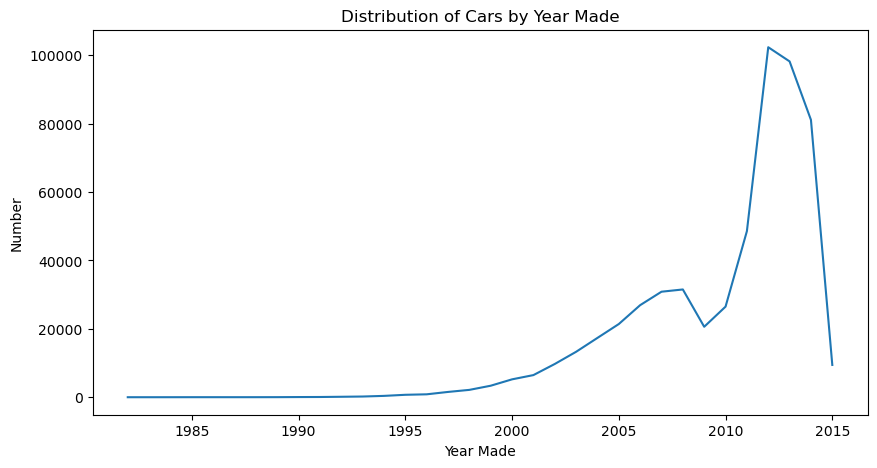

In [9]:
df['year_made'].value_counts().sort_index().plot(kind='line', figsize=(10, 5)); 

plt.xlabel('Year Made') 
plt.ylabel('Number') 
plt.title('Distribution of Cars by Year Made') 

plt.show()

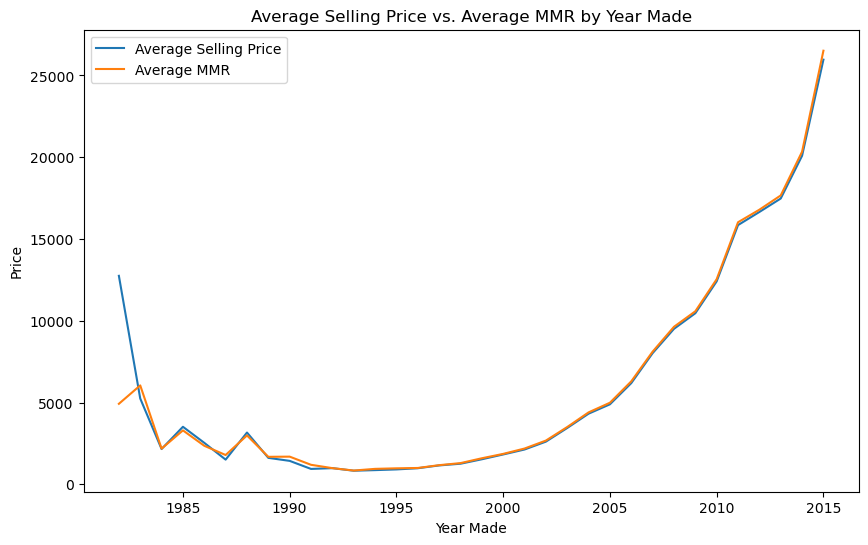

In [10]:
avg_price = df.groupby('year_made')['selling_price'].mean()
avg_mmr = df.groupby('year_made')['mmr'].mean()

combined = pd.DataFrame({
    'Average Selling Price': avg_price,
    'Average MMR': avg_mmr
})

combined.plot(kind='line', figsize=(10, 6))

plt.xlabel('Year Made')
plt.ylabel('Price')
plt.title('Average Selling Price vs. Average MMR by Year Made')

plt.show()

In [13]:
df['maker'].value_counts()

maker
Ford              95598
Chevrolet         61669
Nissan            54237
Toyota            40234
Dodge             31523
Honda             27769
Hyundai           21932
BMW               21273
Chrysler          18666
Kia               18125
Mercedes-Benz     17428
Jeep              15818
Infiniti          15305
Volkswagen        12745
Lexus             12413
GMC               11148
Mazda              8991
Cadillac           7967
Acura              5993
Audi               5922
Lincoln            5893
Subaru             5293
Buick              5154
Mitsubishi         4804
Pontiac            4607
Ram                4574
Volvo              3788
MINI               3224
Saturn             2842
Land Rover         2420
Mercury            2135
Scion              1687
Porsche            1510
Jaguar             1423
Suzuki             1086
FIAT                865
Hummer              808
Saab                486
Oldsmobile          408
Smart               396
Isuzu               204
Maserati  

<Axes: xlabel='maker'>

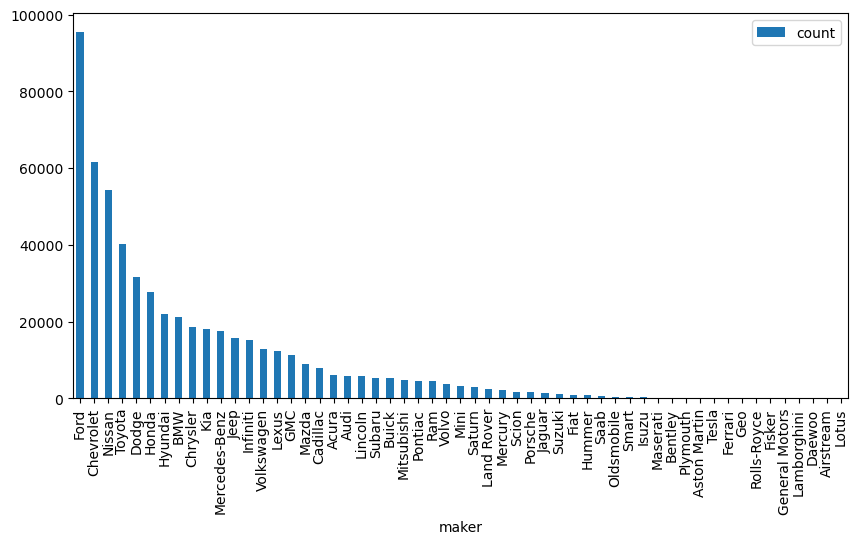

In [70]:
pd.DataFrame(df['maker'].value_counts().sort_values(ascending=False)).plot(kind='bar', figsize=(10, 5))

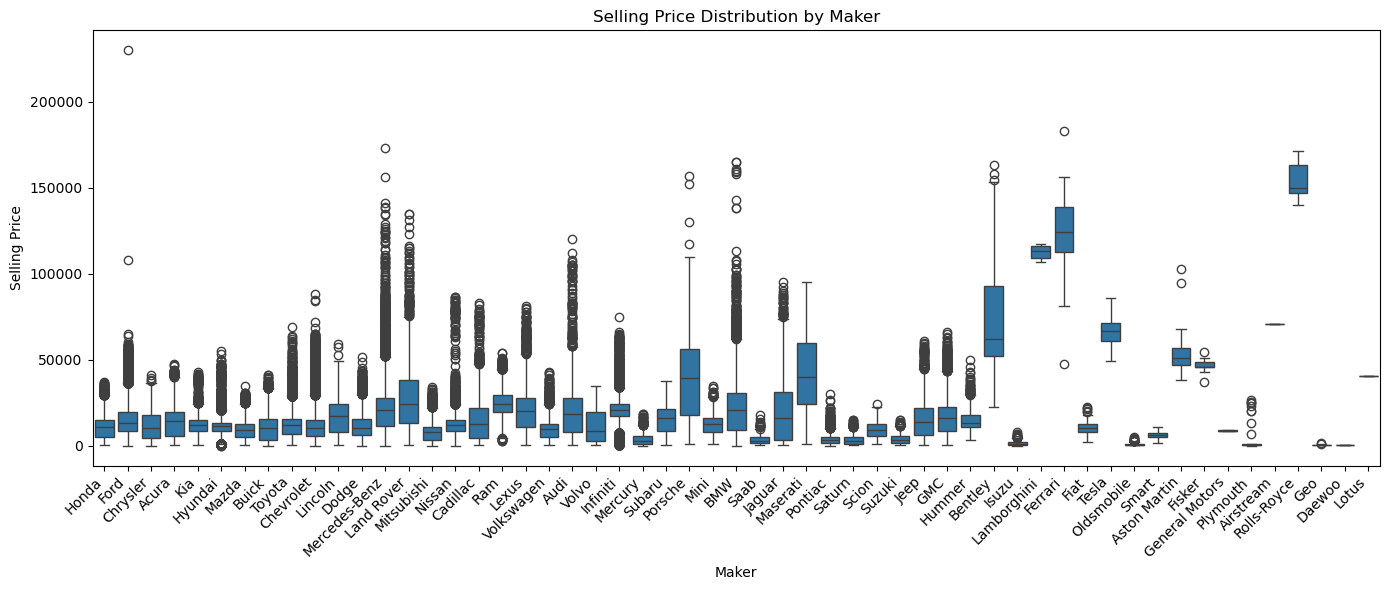

In [63]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='maker', y='selling_price', data=df)
plt.title('Selling Price Distribution by Maker')
plt.ylabel('Selling Price')
plt.xlabel('Maker')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

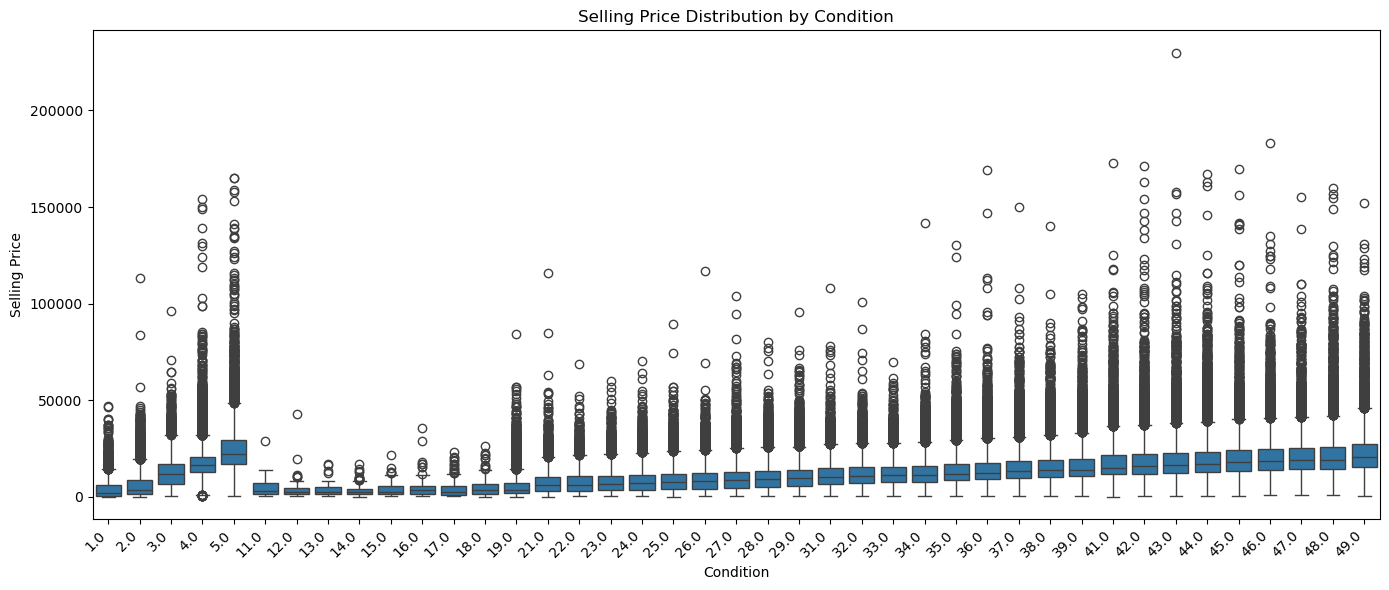

In [110]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='condition', y='selling_price', data=df)
plt.title('Selling Price Distribution by Condition')
plt.ylabel('Selling Price')
plt.xlabel('Condition')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

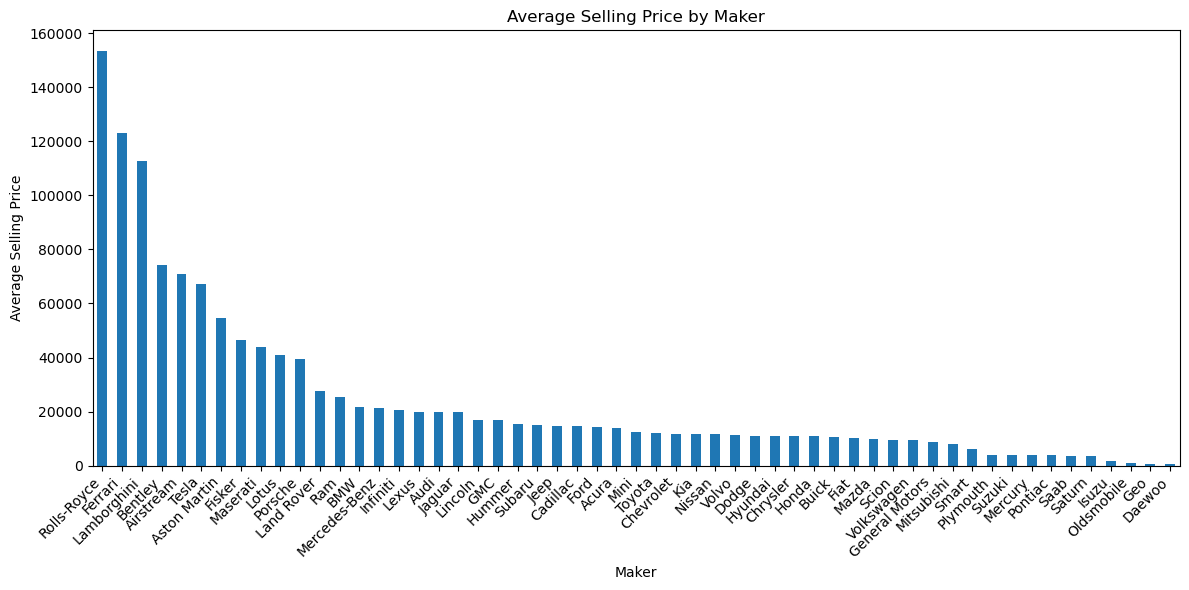

In [66]:
avg_price = df.groupby('maker')['selling_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_price.plot(kind='bar')
plt.title('Average Selling Price by Maker')
plt.ylabel('Average Selling Price')
plt.xlabel('Maker')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

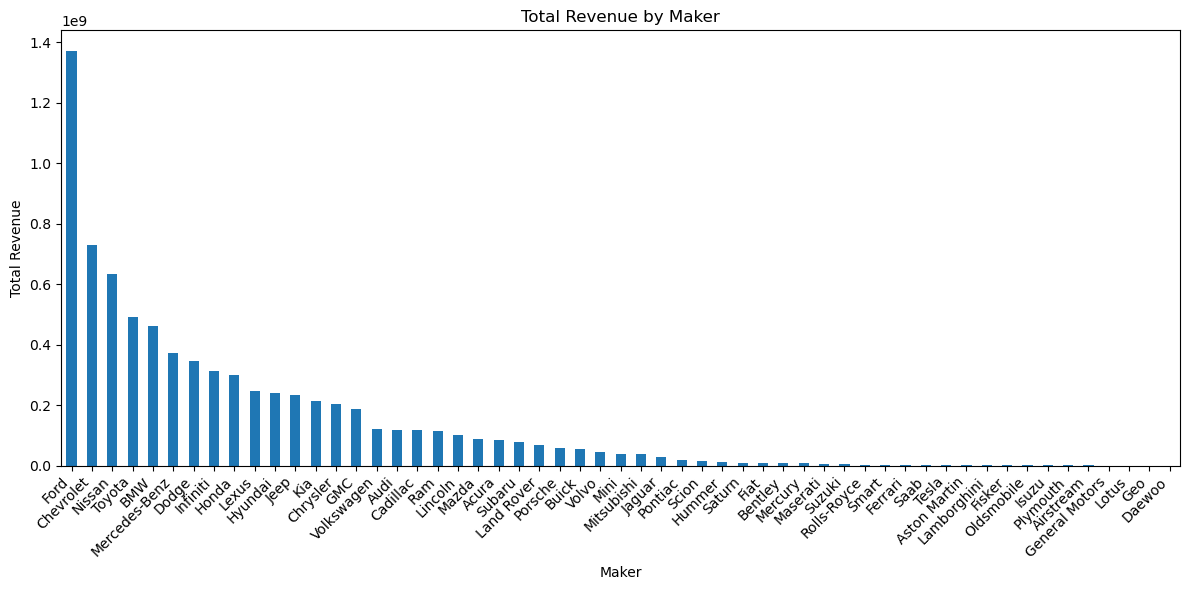

In [79]:
revenue = df.groupby('maker')['selling_price'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
revenue.plot(kind='bar')
plt.title('Total Revenue by Maker')
plt.ylabel('Total Revenue')
plt.xlabel('Maker')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [42]:
df['model'].value_counts()

model
Altima      19349
F-150       14479
Fusion      12946
Camry       12549
Escape      11893
            ...  
Spirit          1
Leganza         1
Le Baron        1
Mountnr         1
Metro           1
Name: count, Length: 849, dtype: int64

In [50]:
df['model'].value_counts().head(10)

model
Altima           19349
F-150            14479
Fusion           12946
Camry            12549
Escape           11893
Focus            10399
Accord            9155
3 Series          8204
Impala            7957
Grand Caravan     7941
Name: count, dtype: int64

In [49]:
df['model'].value_counts().tail(10)

model
C240s       1
42c         1
B2300       1
Regency     1
350         1
Spirit      1
Leganza     1
Le Baron    1
Mountnr     1
Metro       1
Name: count, dtype: int64

In [81]:
df.groupby('model')['selling_price'].sum().sort_values(ascending=False)

model
F-150        272669759.0
Altima       220986008.0
Escape       165966502.0
Fusion       159912520.0
G Sedan      147918806.0
                ...     
Fleetwood          350.0
Leganza            300.0
Spirit             300.0
Regency            300.0
Paseo              150.0
Name: selling_price, Length: 847, dtype: float64

In [83]:
df.groupby('model')['selling_price'].mean().sort_values(ascending=False)

model
458 Italia        183000.000000
SLS AMG GT        156500.000000
I8                154222.222222
Flying Spur       154000.000000
Ghost             153488.235294
                      ...      
Regency              300.000000
300e                 300.000000
Spirit               300.000000
Windstar Cargo       281.250000
Paseo                150.000000
Name: selling_price, Length: 847, dtype: float64

In [51]:
df['trim'].value_counts()

trim
Base                 55842
SE                   43691
LX                   20782
Limited              18369
LT                   16984
                     ...  
fwd ext base             1
exl                      1
4c ls w/1ls              1
4x2 reg silverado        1
Estate                   1
Name: count, Length: 1893, dtype: int64

In [7]:
df['body'].value_counts()

body
Sedan           248786
SUV             143844
Pickup Truck     47540
Hatchback        26237
Minivan          25529
Coupe            20163
Wagon            16180
Other            13195
Convertible      10933
Van               6430
Name: count, dtype: int64

<Axes: xlabel='body'>

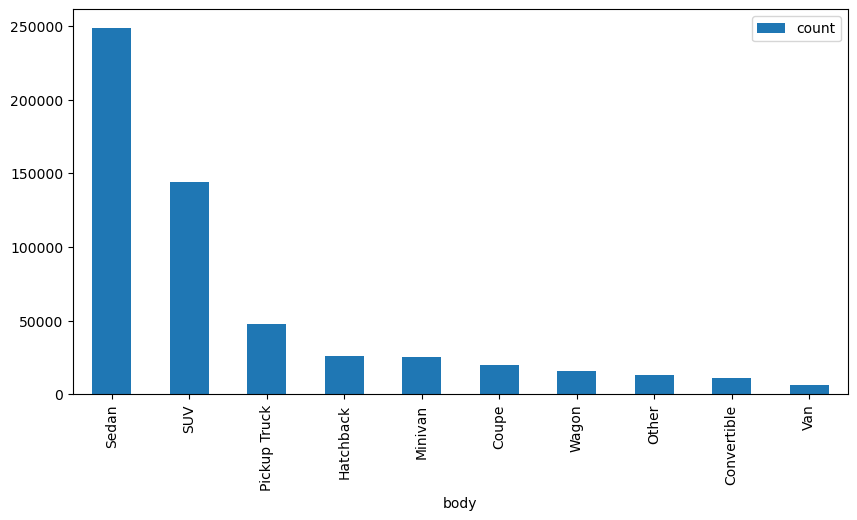

In [71]:
pd.DataFrame(df['body'].value_counts().sort_values(ascending=False)).plot(kind='bar', figsize=(10, 5))

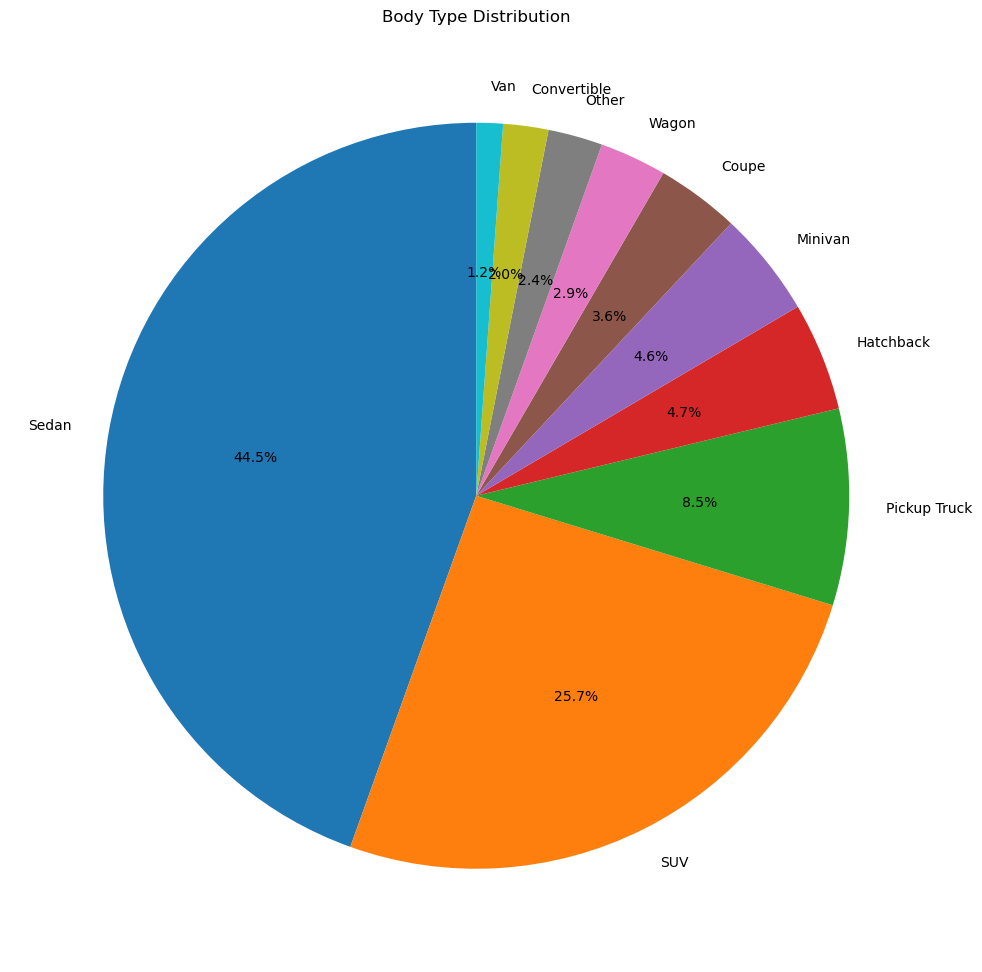

In [10]:
ax = df['body'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(10, 10), title='Body Type Distribution', legend=False)

ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [53]:
df['transmission'].value_counts()

transmission
automatic    475937
manual        17544
Name: count, dtype: int64

<Axes: xlabel='transmission'>

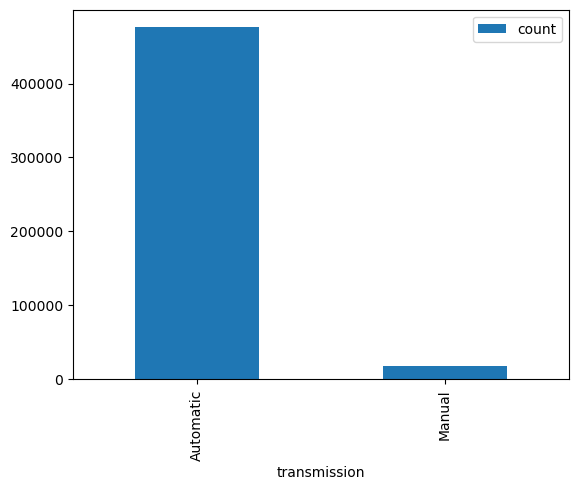

In [12]:
pd.DataFrame(df['transmission'].value_counts().sort_index()).plot(kind='bar')

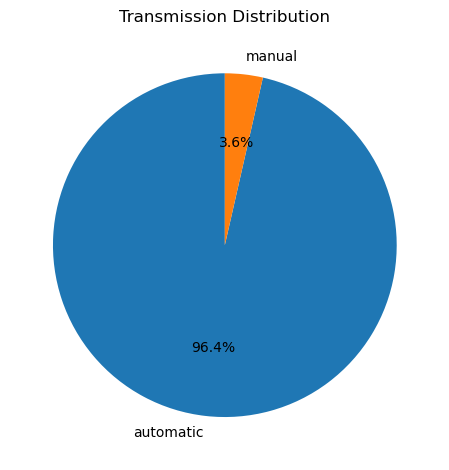

In [54]:
ax = df['transmission'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, title='Transmission Distribution', legend=False)

ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [55]:
df['state'].value_counts()

state
FL    82945
CA    73148
PA    53907
TX    45913
GA    34750
NJ    27784
IL    23486
NC    21845
OH    21575
TN    20895
MO    16013
MI    15511
NV    12685
VA    12027
MD    11158
WI     9851
MN     9429
AZ     8741
CO     7775
WA     7416
MA     6729
NY     5699
IN     4325
SC     4251
NE     4013
ON     3442
PR     2725
LA     2191
MS     1851
UT     1836
QC     1245
HI     1237
OR     1155
AB      928
NM      171
OK       72
NS       61
AL       26
Name: count, dtype: int64

<Axes: xlabel='state'>

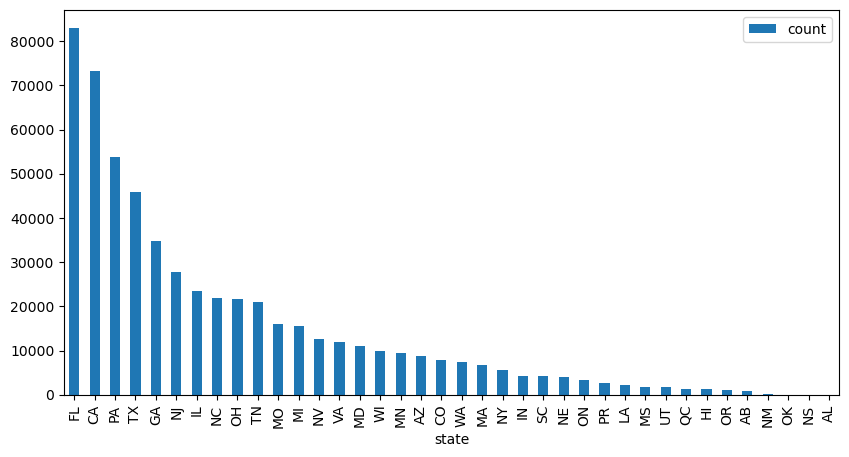

In [72]:
pd.DataFrame(df['state'].value_counts().sort_values(ascending=False)).plot(kind='bar', figsize=(10, 5))

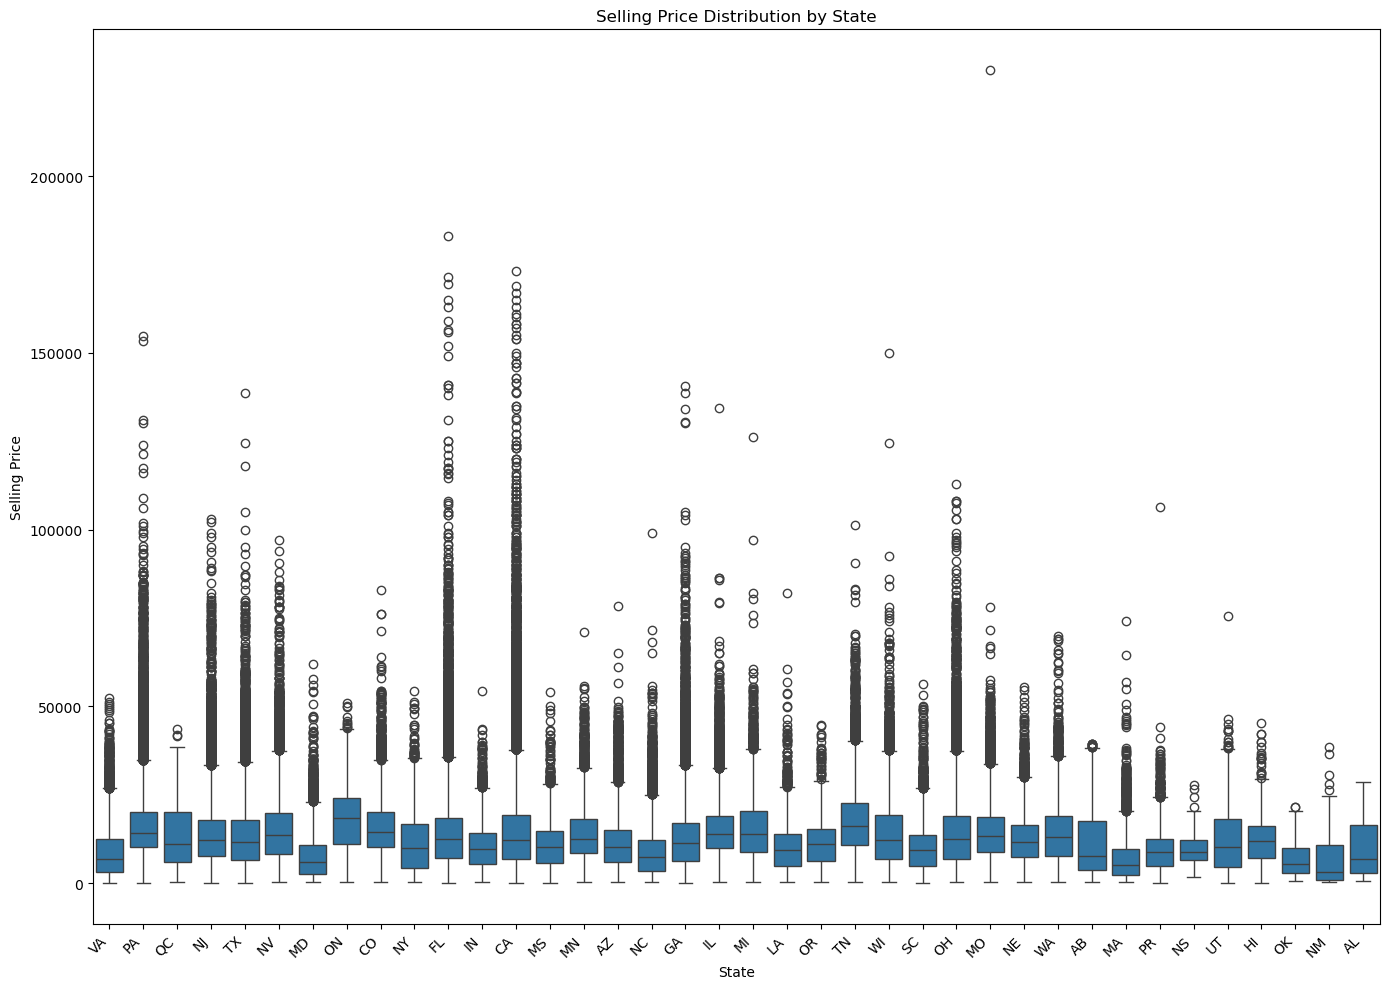

In [126]:
plt.figure(figsize=(14, 10))
sns.boxplot(x='state', y='selling_price', data=df)
plt.title('Selling Price Distribution by State')
plt.ylabel('Selling Price')
plt.xlabel('State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [58]:
df['condition'].value_counts()

condition
19.0    42281
35.0    26750
37.0    25938
44.0    25516
43.0    24937
42.0    24329
36.0    23145
41.0    23075
2.0     20796
4.0     19922
39.0    19920
28.0    19179
29.0    18928
38.0    18725
34.0    17398
27.0    16351
49.0    13100
48.0    12714
46.0    12638
25.0    12561
45.0    12313
26.0    11912
47.0    11363
5.0     11223
3.0     10803
33.0    10619
32.0     9962
24.0     9326
31.0     9222
21.0     9199
23.0     8188
1.0      7367
22.0     6057
18.0      323
17.0      243
16.0      178
15.0      144
14.0      134
12.0       95
11.0       87
13.0       82
Name: count, dtype: int64

<Axes: xlabel='condition'>

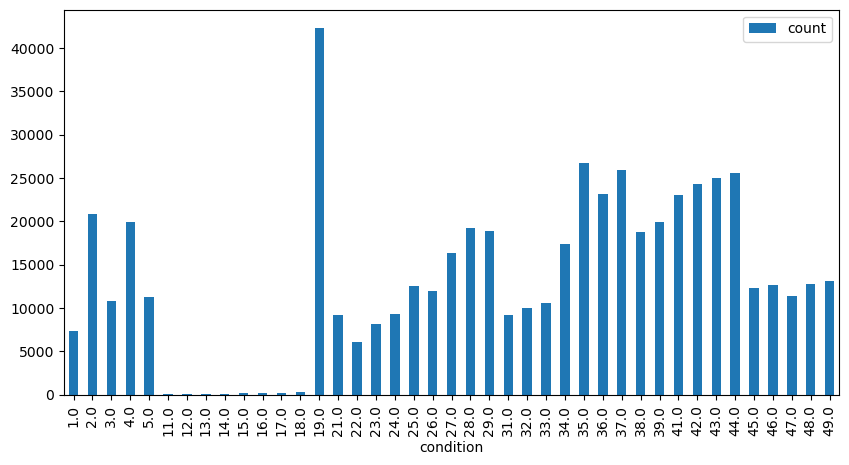

In [10]:
pd.DataFrame(df['condition'].value_counts().sort_index()).plot(kind='bar', figsize=(10, 5))

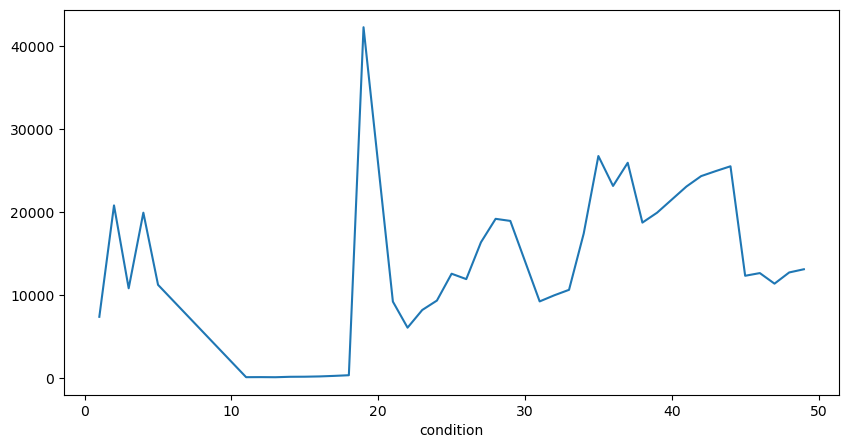

In [9]:
df['condition'].value_counts().sort_index().plot(kind='line', figsize=(10, 5)); 
plt.show()

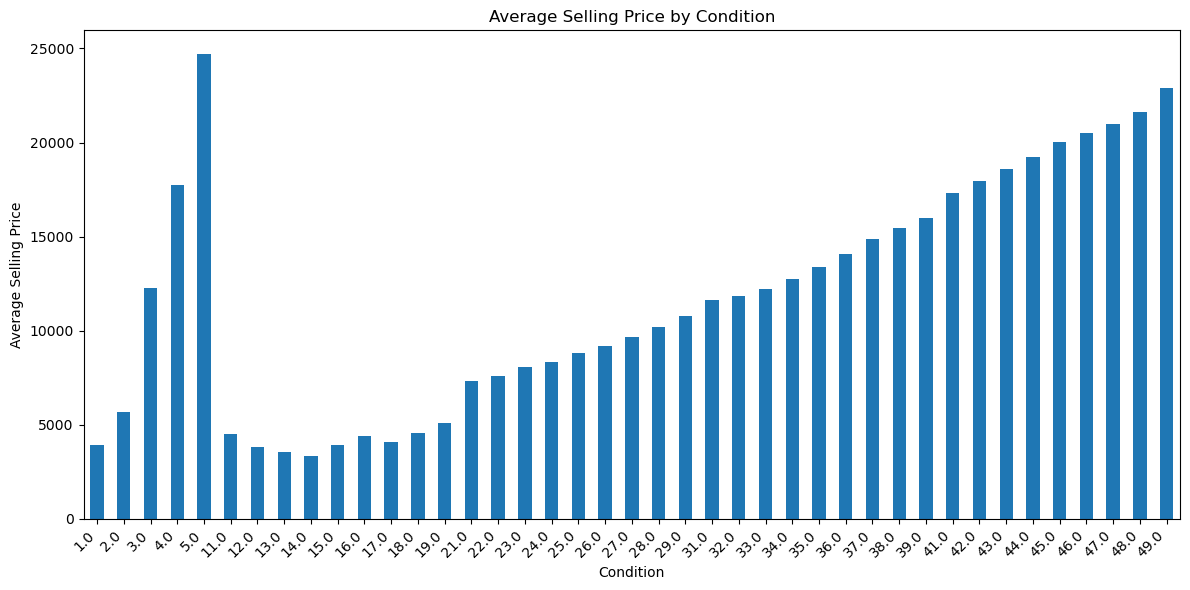

In [103]:
Selling_Price_by_Condition = df.groupby('condition')['selling_price'].mean().sort_index()

plt.figure(figsize=(12, 6))
revenue.plot(kind='bar')
plt.title('Average Selling Price by Condition')
plt.ylabel('Average Selling Price')
plt.xlabel('Condition')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
df['odometer_miles'].value_counts()

odometer_miles
1         1315
0           94
999999      72
10          29
21587       21
          ... 
194644       1
107920       1
232934       1
120048       1
254931       1
Name: count, Length: 172281, dtype: int64

In [16]:
df['odometer_miles'] = df['odometer_miles'].fillna(0).astype(int)

In [17]:
df['odometer_miles'] = df['odometer_miles'].astype(int)

print("\nAfter:")
print(df.dtypes)


After:
year_made           int64
maker              object
model              object
trim               object
transmission       object
vin                object
state              object
condition         float64
odometer_miles      int32
color              object
interior           object
seller             object
mmr               float64
selling_price     float64
sale_time          object
sale_date          object
maker_region       object
sale_year          object
sale_month         object
body               object
dtype: object


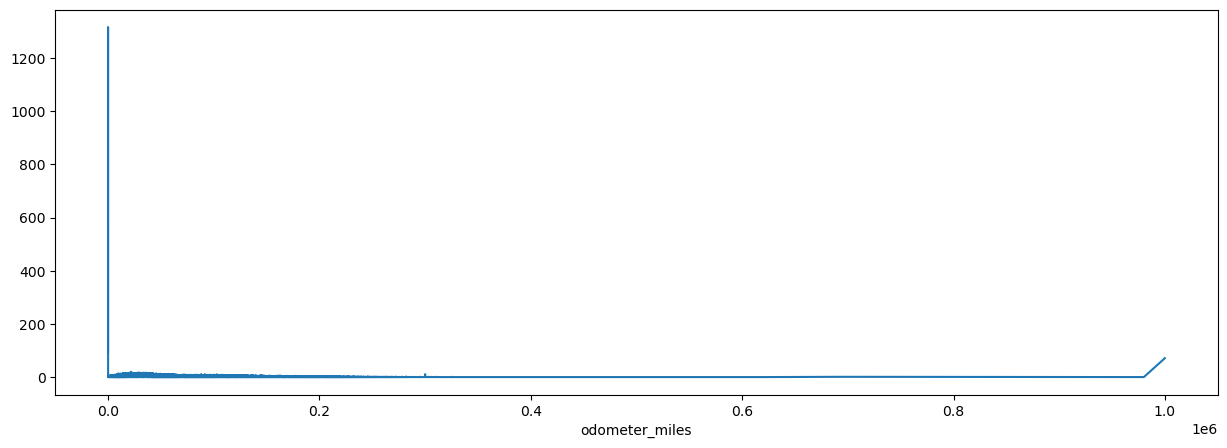

In [18]:
df['odometer_miles'].value_counts().sort_index().plot(kind='line', figsize=(15, 5)); 
plt.show()

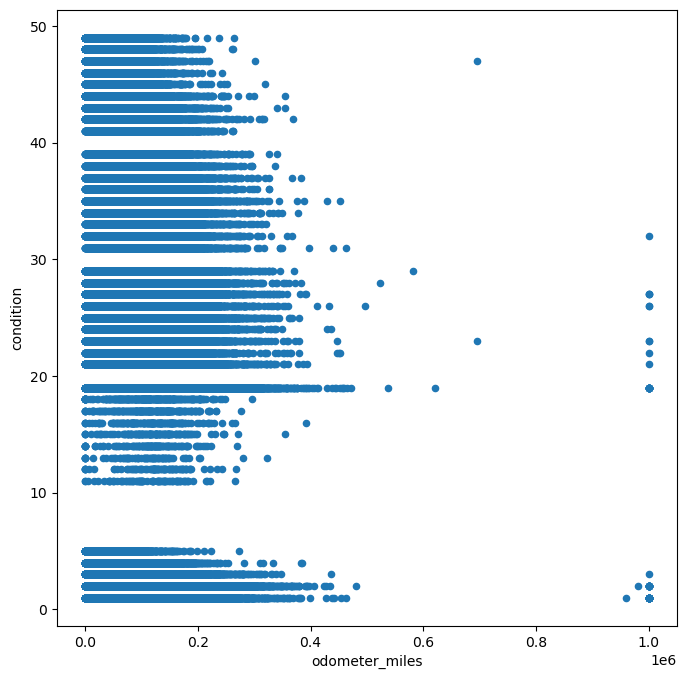

In [85]:
df.plot(kind='scatter', x='odometer_miles', y='condition', figsize=(8,8))
plt.show()

In [75]:
df['color'].value_counts()

color
black        110974
white        106677
silver        83394
gray          82860
blue          51144
red           43573
green         11382
gold          11342
beige          9222
burgundy       8972
brown          6717
orange         2078
purple         1561
off-white      1449
yellow         1285
charcoal        479
turquoise       236
pink             42
lime             15
Name: count, dtype: int64

<Axes: xlabel='color'>

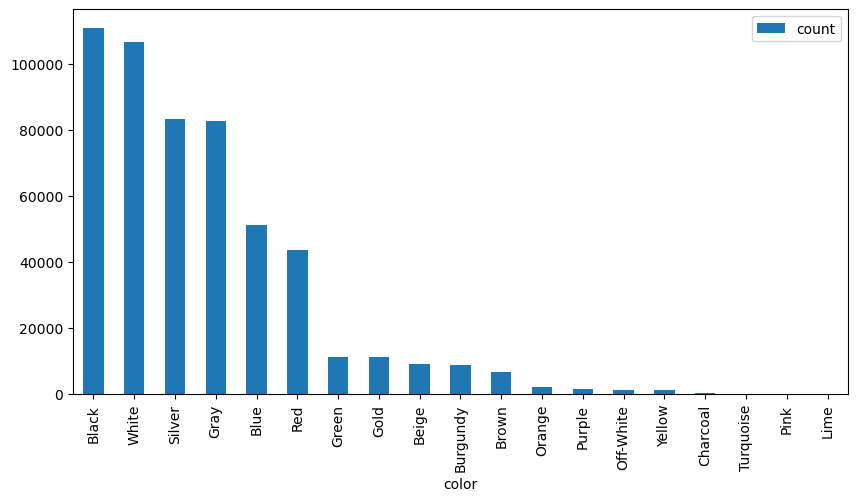

In [73]:
pd.DataFrame(df['color'].value_counts().sort_values(ascending=False)).plot(kind='bar', figsize=(10, 5))

In [82]:
df['interior'].value_counts()

interior
black        244347
gray         178582
beige         59758
tan           44093
brown          8640
red            1359
blue           1138
silver         1099
off-white       480
purple          339
gold            324
white           252
green           245
burgundy        191
orange          145
yellow           20
Name: count, dtype: int64

<Axes: xlabel='interior'>

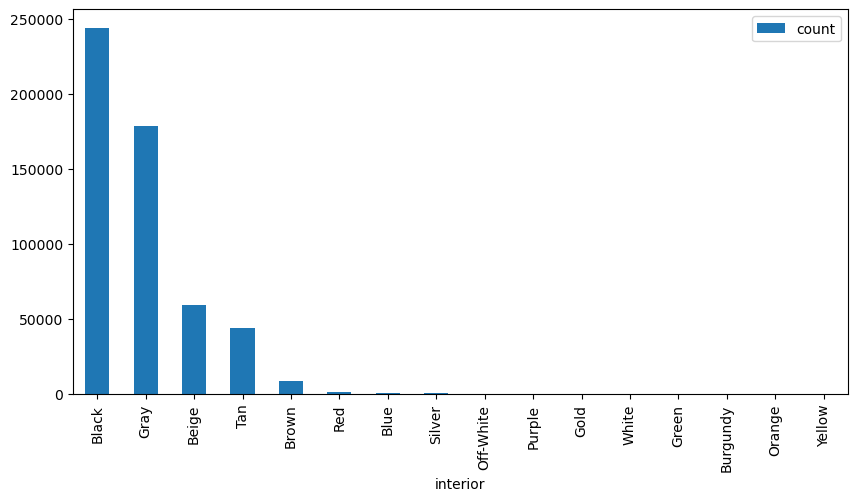

In [74]:
pd.DataFrame(df['interior'].value_counts().sort_values(ascending=False)).plot(kind='bar', figsize=(10, 5))

In [7]:
df['seller'].value_counts()

seller
nissan-infiniti lt               19693
ford motor credit company llc    19162
the hertz corporation            18299
santander consumer               15285
avis corporation                 12540
                                 ...  
storm motors miami llc               1
778025 alberta ltd                   1
thompson mazda                       1
auction cars imports llc             1
flag/audi fort myers                 1
Name: count, Length: 14261, dtype: int64

In [27]:
df['mmr'].value_counts()

mmr
12500.0     1761
11600.0     1751
11650.0     1746
12150.0     1722
11850.0     1717
            ... 
156000.0       1
157000.0       1
178000.0       1
182000.0       1
132000.0       1
Name: count, Length: 1101, dtype: int64

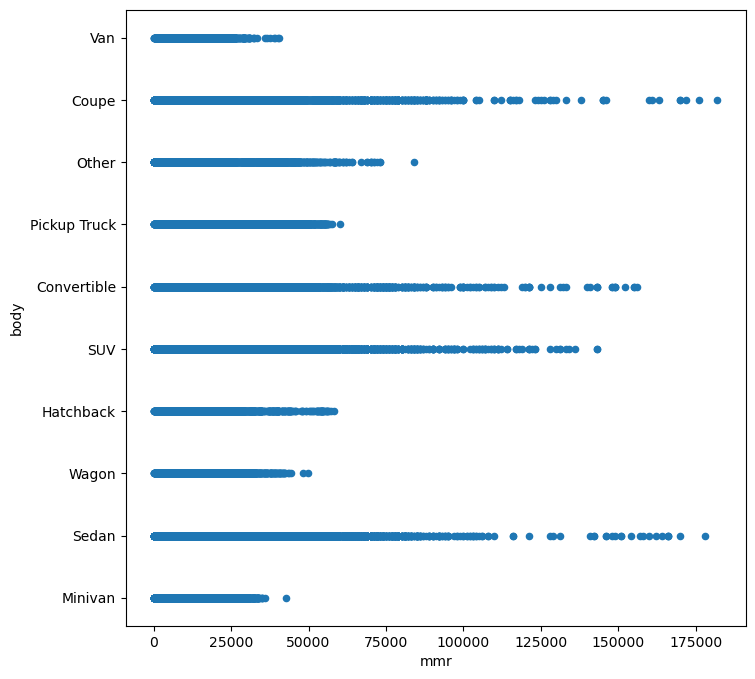

In [86]:
df.plot(kind='scatter', x='mmr', y='body', figsize=(8,8))
plt.show()

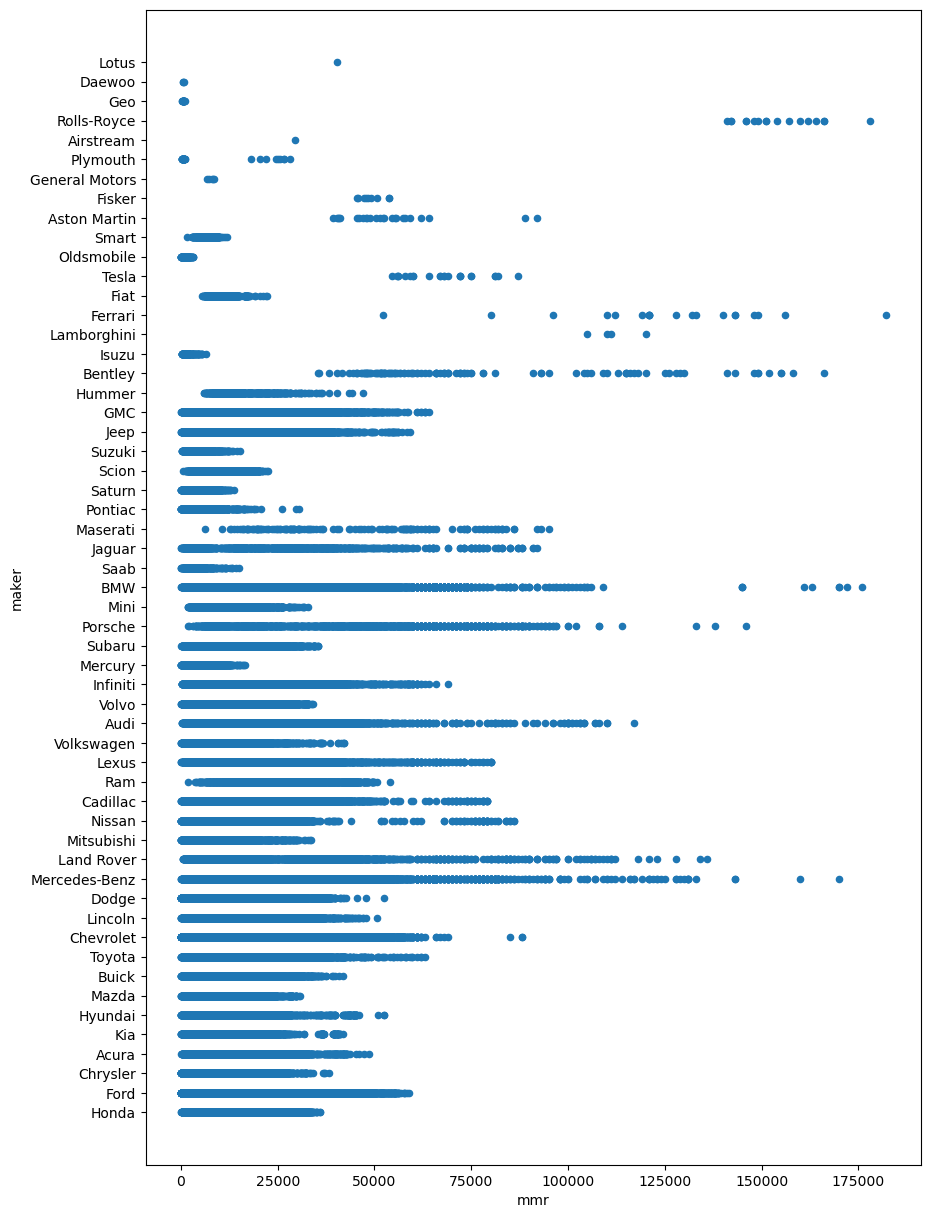

In [32]:
df.dropna(subset=['maker']).plot(kind='scatter',x='mmr',y='maker',figsize=(10, 15))
plt.show()

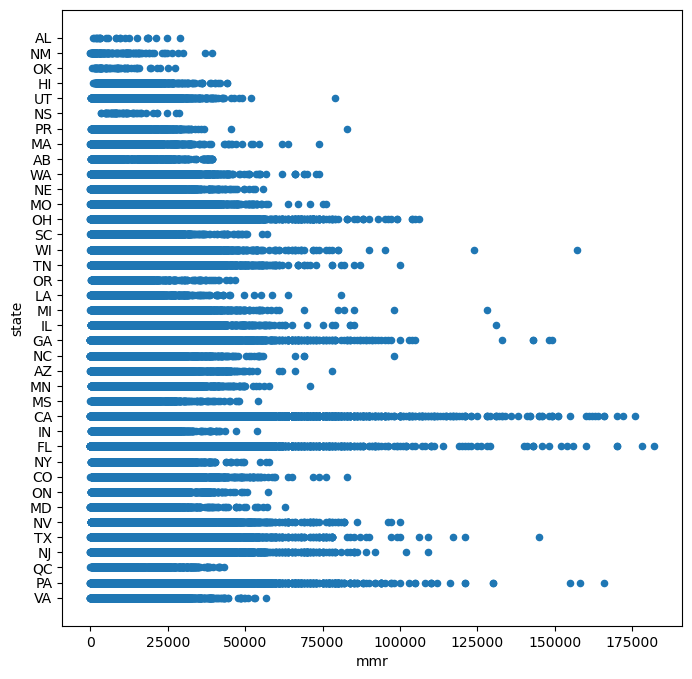

In [87]:
df.dropna(subset=['state']).plot(kind='scatter',x='mmr',y='state',figsize=(8, 8))
plt.show()

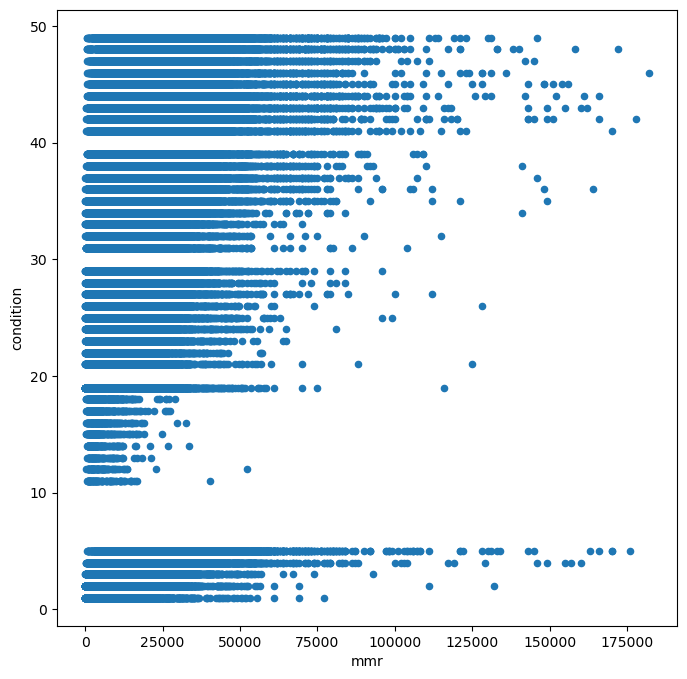

In [33]:
df.dropna(subset=['condition']).plot(kind='scatter',x='mmr',y='condition',figsize=(8, 8))
plt.show()

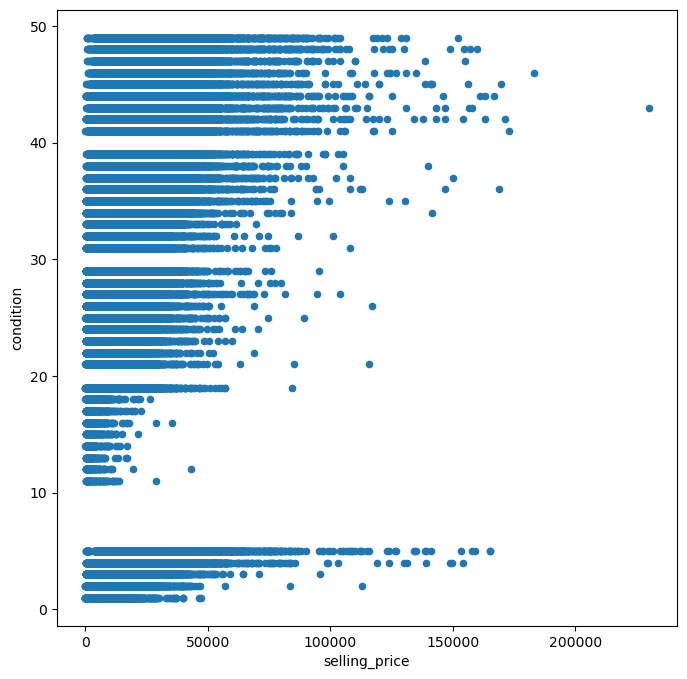

In [32]:
df.dropna(subset=['condition']).plot(kind='scatter',x='selling_price',y='condition',figsize=(8, 8))
plt.show()

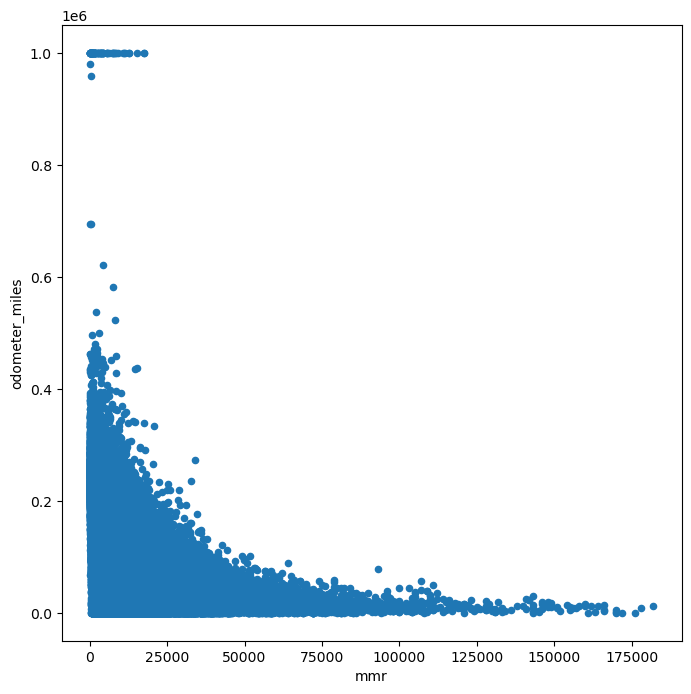

In [23]:
df.dropna(subset=['odometer_miles']).plot(kind='scatter',x='mmr',y='odometer_miles',figsize=(8, 8))
plt.show()

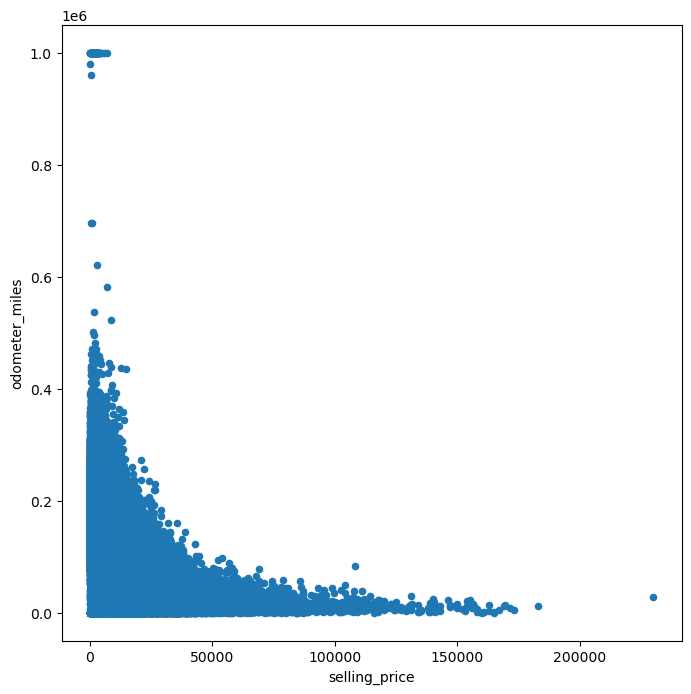

In [24]:
df.dropna(subset=['odometer_miles']).plot(kind='scatter',x='selling_price',y='odometer_miles',figsize=(8, 8))
plt.show()

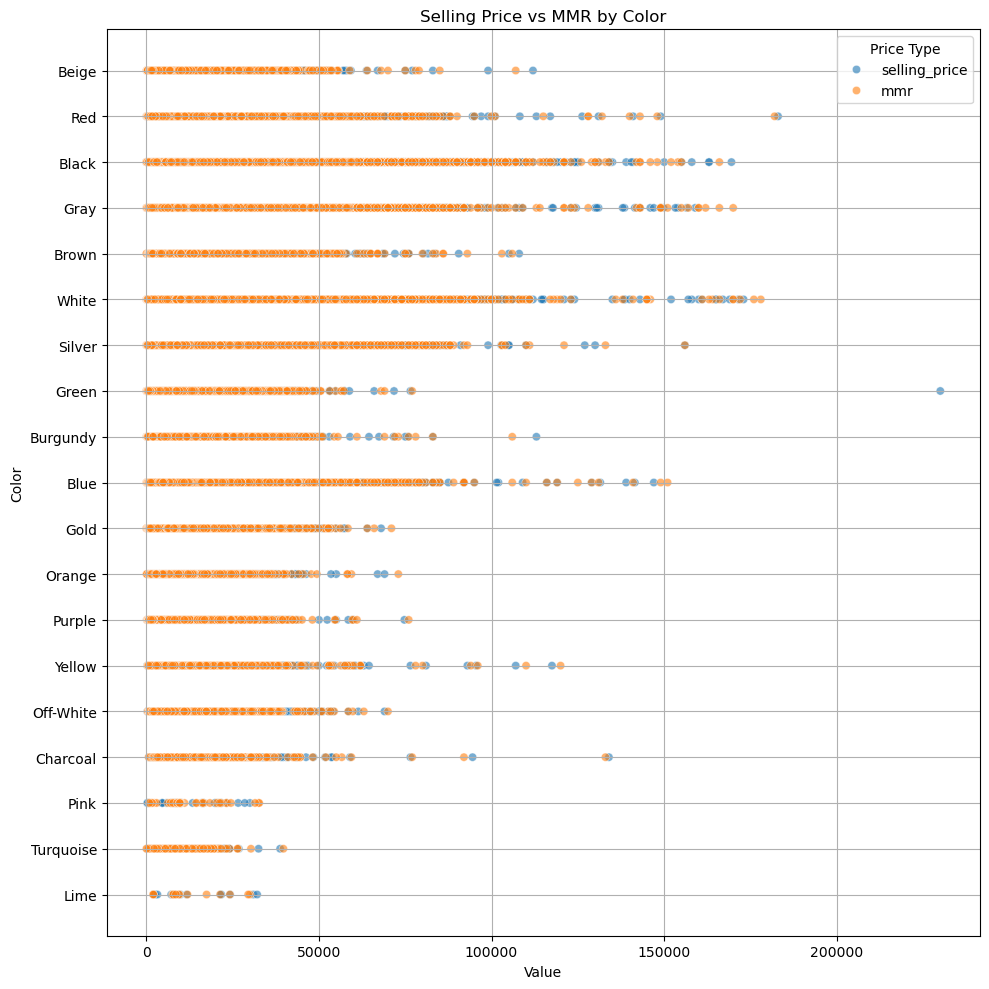

In [20]:
import seaborn as sns

df_melted = df[['color', 'selling_price', 'mmr']].melt(
    id_vars='color',
    value_vars=['selling_price', 'mmr'],
    var_name='Price_Type',
    value_name='Value'
)

df_melted = df_melted.dropna()

plt.figure(figsize=(10, 10))
sns.scatterplot(data=df_melted, x='Value', y='color', hue='Price_Type', alpha=0.6)

plt.title('Selling Price vs MMR by Color')
plt.xlabel('Value')
plt.ylabel('Color')
plt.grid(True)
plt.legend(title='Price Type')
plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_10592\1317373968.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\PC\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


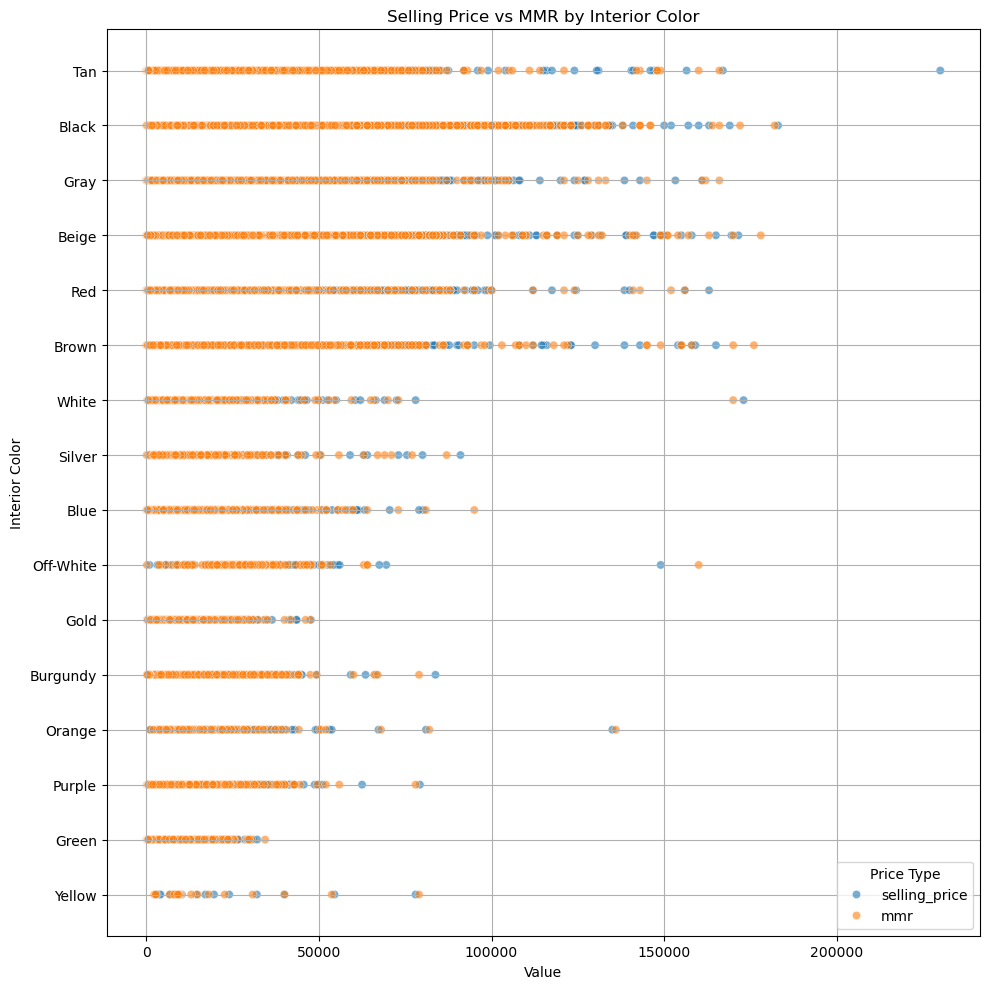

In [31]:
df_melted = df[['interior', 'selling_price', 'mmr']].melt(
    id_vars='interior',
    value_vars=['selling_price', 'mmr'],
    var_name='Price_Type',
    value_name='Value'
)

df_melted = df_melted.dropna()

plt.figure(figsize=(10, 10))
sns.scatterplot(data=df_melted, x='Value', y='interior', hue='Price_Type', alpha=0.6)

plt.title('Selling Price vs MMR by Interior Color')
plt.xlabel('Value')
plt.ylabel('Interior Color')
plt.grid(True)
plt.legend(title='Price Type')
plt.tight_layout()
plt.show()

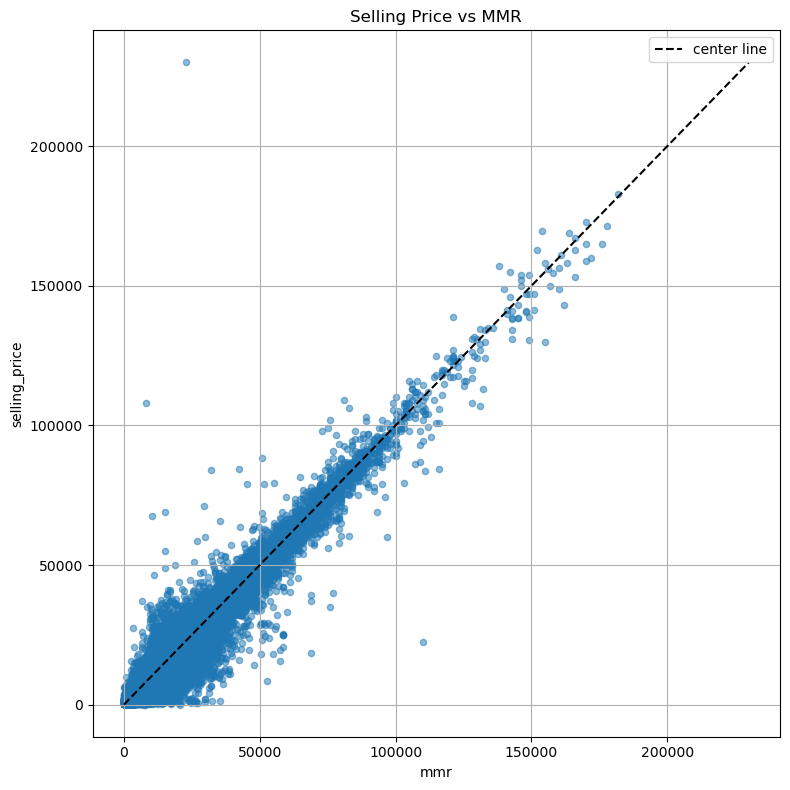

In [29]:
df_filtered = df.dropna(subset=['selling_price', 'mmr'])

ax = df_filtered.plot(kind='scatter', x='mmr', y='selling_price', figsize=(8, 8), alpha=0.5)

min_val = min(df_filtered['mmr'].min(), df_filtered['selling_price'].min())
max_val = max(df_filtered['mmr'].max(), df_filtered['selling_price'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='center line')

plt.legend()
plt.title('Selling Price vs MMR')
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
df['maker_region'].value_counts()

maker_region
USA                    288905
Canada                  73097
Japan                   64118
Mexico                  51748
Germany                 46871
South Korea             23754
UK                       4264
Sweden/Finland           4220
Turkey                    700
Italy                     474
Australia                 209
India                     189
Hungary/Switzerland       143
Brazil                    106
France/Spain               39
Name: count, dtype: int64

<Axes: xlabel='maker_region'>

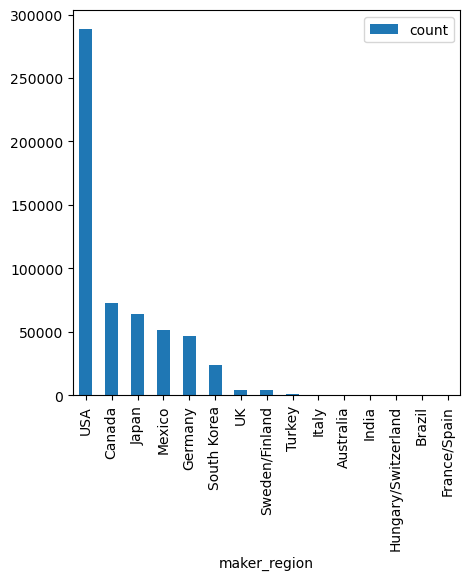

In [75]:
pd.DataFrame(df['maker_region'].value_counts().sort_values(ascending=False)).plot(kind='bar', figsize=(5, 5))

In [29]:
df['sale_month'].value_counts()

sale_month
Feb    163053
Jan    140815
Jun     99937
Dec     53520
May     52447
Mar     46277
Apr      1450
Jul      1300
Name: count, dtype: int64

<Axes: xlabel='sale_month'>

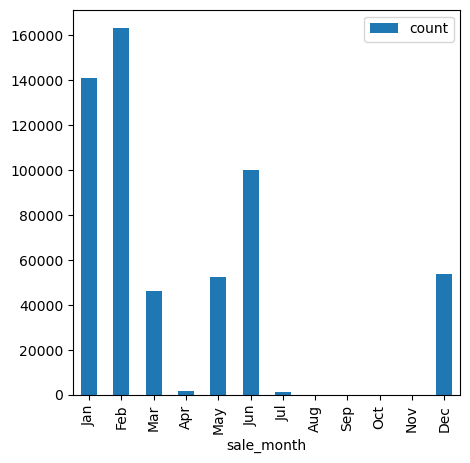

In [77]:
pd.DataFrame(df['sale_month'].value_counts().sort_index()).plot(kind='bar', figsize=(5, 5))

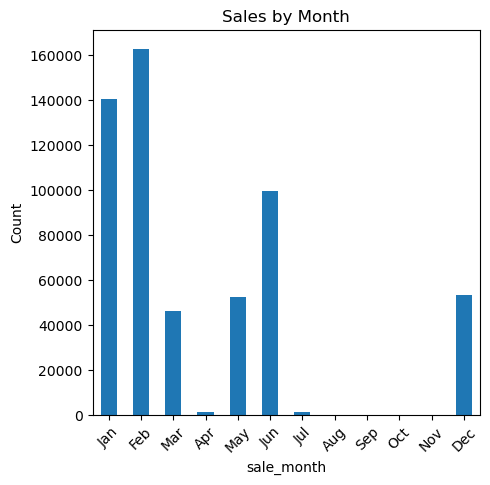

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df['sale_month'] = pd.Categorical(df['sale_month'], categories=month_order, ordered=True)

(
    pd.DataFrame(df['sale_month'].value_counts(sort=False).reindex(month_order, fill_value=0))
    .plot(kind='bar', figsize=(5, 5), legend=False)
)
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Sales by Month")
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_10592\180266171.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['month_num'] = df_clean['sale_month'].cat.codes


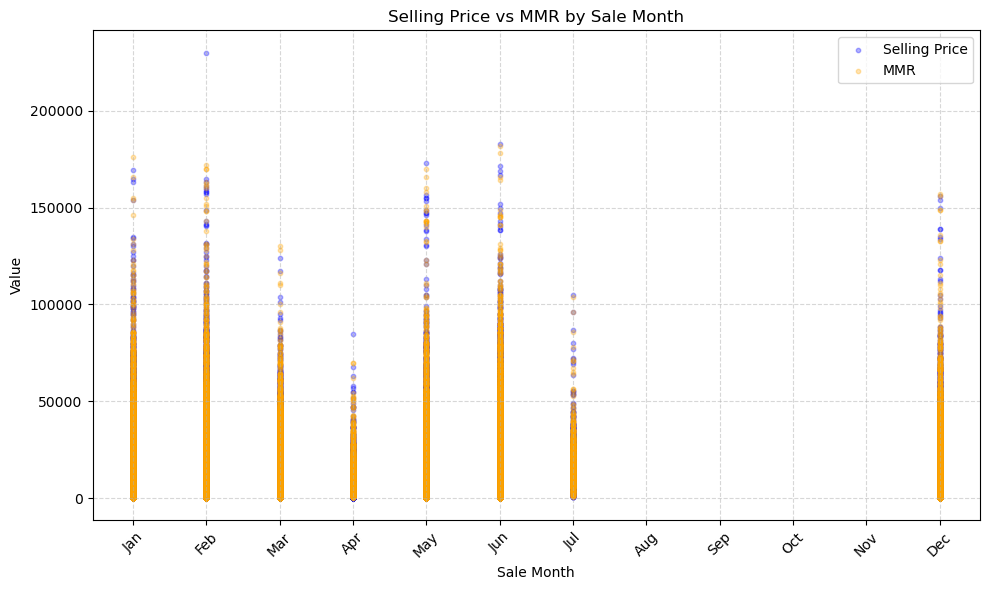

In [42]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df['sale_month'] = pd.Categorical(df['sale_month'], categories=month_order, ordered=True)

df_clean = df.dropna(subset=['sale_month', 'selling_price', 'mmr'])

df_clean['month_num'] = df_clean['sale_month'].cat.codes

plt.figure(figsize=(10, 6))

plt.scatter(df_clean['month_num'], df_clean['selling_price'], 
            alpha=0.3, s=10, color='blue', label='Selling Price')

plt.scatter(df_clean['month_num'], df_clean['mmr'], 
            alpha=0.3, s=10, color='orange', label='MMR')

plt.xticks(ticks=range(12), labels=month_order, rotation=45)
plt.xlabel('Sale Month')
plt.ylabel('Value')
plt.title('Selling Price vs MMR by Sale Month')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<Axes: xlabel='sale_year'>

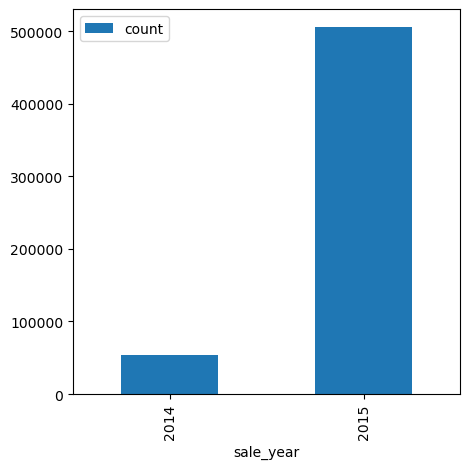

In [24]:
pd.DataFrame(df['sale_year'].value_counts().sort_index()).plot(kind='bar', figsize=(5, 5))